In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from glob import glob

DATA_PATHS = sorted(glob("Data/Preparatory/*.mat"))
DATA_PATHS

['Data/Preparatory/P_250323.mat',
 'Data/Preparatory/P_250324.mat',
 'Data/Preparatory/P_250327.mat',
 'Data/Preparatory/P_250408.mat',
 'Data/Preparatory/P_250409.mat',
 'Data/Preparatory/P_251114.mat',
 'Data/Preparatory/P_251209.mat']

In [5]:
def bin_spikes_counts(data, bin_size=20):
    """
    data: (trials, time, neurons)
    bin_size: in timesteps (e.g., 20 if 1 ms bins)
    """
    T = data.shape[1]
    T_trim = (T // bin_size) * bin_size
    
    data_trim = data[:, :T_trim, :]
    
    binned = data_trim.reshape(
        data.shape[0],
        T_trim // bin_size,
        bin_size,
        data.shape[2]
    ).sum(axis=2)  #key: SUM, not mean
    
    return binned



In [6]:
import h5py

f = h5py.File(DATA_PATHS[-1], 'r')

spike_tensor = f['spike_tensor'][:].T        # (trials, time, neurons)
trial_conditions = f['trial_conditions'][:].flatten() - 1 

print(spike_tensor.shape)
print(trial_conditions.shape)

(2028, 601, 378)
(2028,)


In [7]:
spike_tensor_binned = bin_spikes_counts(spike_tensor, bin_size=5)
print(spike_tensor_binned.shape)

(2028, 120, 378)


In [8]:
import numpy as np
from scipy.stats import norm
from scipy.signal import lfilter

def filter_gauss(spike_tensor, SD):
    """
    spike_tensor: (trials, time, neurons)
    SD: standard deviation in ms (same units as time bins)
    
    returns:
        smoothed firing rate (same shape), in spikes/ms
    """

    # --- Gaussian kernel ---
    SDrounded = int(2 * round(SD / 2))
    gausswidth = int(8 * SDrounded)

    x = np.arange(1, gausswidth + 1)
    F = norm.pdf(x, loc=gausswidth / 2, scale=SD)
    F = F / np.sum(F)

    shift = len(F) // 2

    n_trials, T, n_neurons = spike_tensor.shape

    # --- padding with mean (like MATLAB) ---
    start_mean = np.mean(spike_tensor[:, :SDrounded, :], axis=1, keepdims=True)
    end_mean   = np.mean(spike_tensor[:, -SDrounded:, :], axis=1, keepdims=True)

    pad_start = np.repeat(start_mean, shift, axis=1)
    pad_end   = np.repeat(end_mean, shift, axis=1)

    prefilt = np.concatenate([pad_start, spike_tensor, pad_end], axis=1)

    # --- filtering (causal, along time axis=1) ---
    postfilt = lfilter(F, 1, prefilt, axis=1)

    # --- trim (same as MATLAB) ---
    out = postfilt[:, 2*shift : 2*shift + T, :]

    return out

In [9]:
smth_spikes = filter_gauss(spike_tensor_binned, SD=25/5) * 1000

In [10]:
sess_psths = []
for cond in np.unique(trial_conditions):
    psth = np.mean(smth_spikes[trial_conditions == cond], axis=0)
    sess_psths.append(psth)

psths = np.array(sess_psths)
psths.shape

(6, 120, 378)

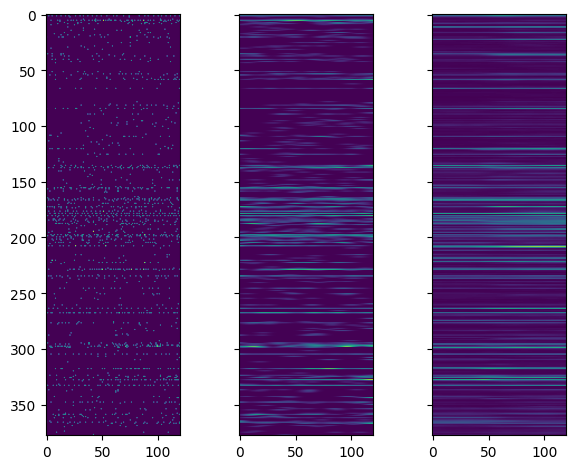

In [11]:
condition = 0
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, sharey=True)
_ = ax1.imshow(spike_tensor_binned[trial_conditions == condition][1].T)
_ = ax2.imshow(smth_spikes[trial_conditions == condition][1].T)
_ = ax3.imshow(psths[condition].T)
plt.tight_layout()

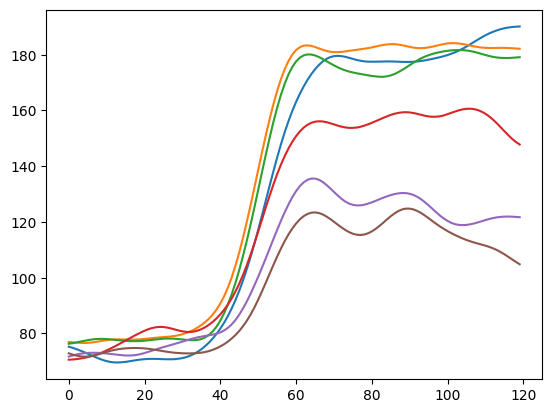

In [12]:
for condition in np.unique(trial_conditions):
    plt.plot(psths[int(condition)].T[1])     

# PCA 

In [13]:
# Cross condition mean 

psths_ccm = np.mean(psths, axis=0)

psths_normalized = psths - psths_ccm 

psths_normalized = psths_normalized / np.std(psths_normalized, axis=(0, 1), keepdims=True)
psths_reshaped = psths_normalized.reshape(-1, psths.shape[-1])
psths_reshaped.shape

(720, 378)

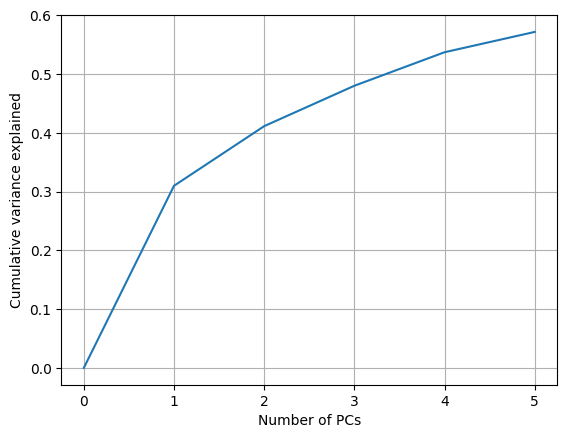

In [14]:
from sklearn.decomposition import PCA

n_components = 5
# Perform PCA on mean-centered data
#combined_psths_ctrd = psths_reshaped - np.mean(psths_reshaped, axis=0)

#combined_psths_ctrd = psths_reshaped/ np.std(psths_reshaped, axis=0)
pca = PCA(n_components).fit(psths_reshaped)
combined_psth_pcs = pca.transform(psths_reshaped)
# Plot the cumulative variance explained
cumvar_expl = np.concatenate([[0], np.cumsum(pca.explained_variance_ratio_)])
#print(f"{np.where(cumvar_expl > 0.9)[0][0]} PCs needed to explain 90% of variance.")
plt.plot(cumvar_expl)
plt.grid()
plt.xlabel("Number of PCs")
_ = plt.ylabel("Cumulative variance explained")

In [15]:
combined_psth_pcs.shape

combined_psth_pcs.shape
psth_pcs = combined_psth_pcs.reshape(psths.shape[0], psths.shape[1], n_components)

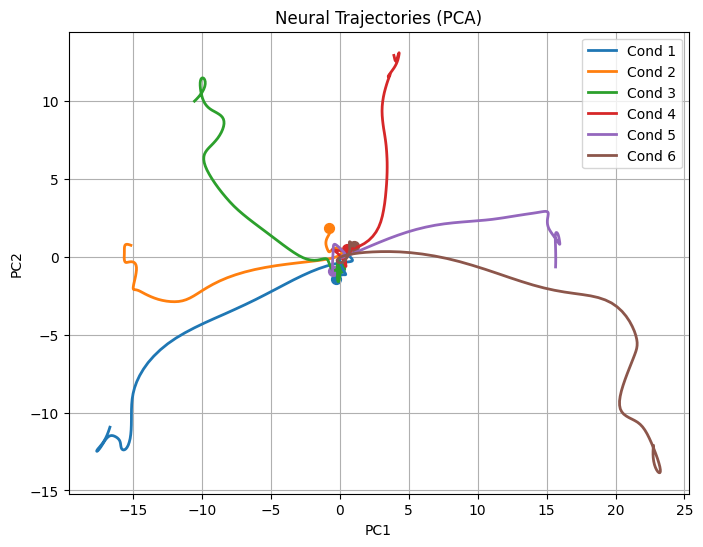

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Parameters ---
n_conditions, n_timesteps, n_components = psth_pcs.shape  # psth_pcs = (conditions × time × PCs)
colors = sns.color_palette("tab10", n_conditions)         # choose nice colors for conditions
condition_labels = [f"Cond {i+1}" for i in range(n_conditions)]

# --- Create 2D figure ---
fig, ax = plt.subplots(figsize=(8, 6))

# --- Plot trajectories ---
for c in range(n_conditions):
    traj = psth_pcs[c]        # shape (time × n_components)
    ax.plot(
        traj[:, 0],            # PC1
        traj[:, 1],            # PC2
        color=colors[c],
        linewidth=2,
        label=condition_labels[c]
    )
    # mark start point
    ax.scatter(traj[0, 0], traj[0, 1], color=colors[c], s=50, marker='o')

# --- Labels and title ---
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Neural Trajectories (PCA)')
ax.legend()
ax.grid(True)

plt.show()

In [17]:
trials_conditions_idx = np.array([np.where(trial_conditions == condition)[0] for condition in np.unique(trial_conditions)], dtype=object)

In [19]:
# Save data for LFADS 

import os
import h5py


vlen_dtype = h5py.vlen_dtype(np.int64)


data_dir = "../../datasets/"
os.makedirs(data_dir, exist_ok=True)

# Assign every 5th trial (20%) to the validation set
sess_spikes = spike_tensor_binned
sess_psths = psths
train_inds, valid_inds = [], []
for i in range(len(sess_spikes)):
    if (i % 5) == 0:
        valid_inds.append(i)
    else:
        train_inds.append(i)
train_inds = np.array(train_inds)
valid_inds = np.array(valid_inds)

train_cond_idx = np.array([np.where(trial_conditions[train_inds] == condition)[0] for condition in np.unique(trial_conditions[train_inds])], dtype=object)
valid_cond_idx = np.array([np.where(trial_conditions[valid_inds] == condition)[0] for condition in np.unique(trial_conditions[valid_inds])], dtype=object)
print("Train condition indices:", train_cond_idx.shape, "Valid condition indices:", valid_cond_idx.shape)
# Write the data for each session to its own file
kwargs = dict(dtype='float32', compression='gzip')
with h5py.File(f"{data_dir}/logic_sr_{251209}_preparatory.h5", 'w') as h5f:
    h5f.create_dataset('train_encod_data', data=sess_spikes[train_inds], **kwargs)
    h5f.create_dataset('valid_encod_data', data=sess_spikes[valid_inds], **kwargs)
    h5f.create_dataset('train_recon_data', data=sess_spikes[train_inds], **kwargs)
    h5f.create_dataset('valid_recon_data', data=sess_spikes[valid_inds], **kwargs)
    h5f.create_dataset('train_inds', data=train_inds, **kwargs)
    h5f.create_dataset('valid_inds', data=valid_inds, **kwargs)
    h5f.create_dataset('train_cond_idx', data=train_cond_idx, dtype=vlen_dtype)
    h5f.create_dataset('valid_cond_idx', data=valid_cond_idx, dtype=vlen_dtype)
    h5f.create_dataset('psth', data=psths, **kwargs)

Train condition indices: (6,) Valid condition indices: (6,)


In [2]:
from lfads_torch.run_model import run_model
from datetime import datetime
from pathlib import Path


PROJECT_STR = "lfads-torch-logic-251209_preparatory"
DATASET_STR = "logic_sr_251209_preparatory"
RUN_TAG = datetime.now().strftime("%y%m%d")
RUN_DIR = Path("/path/to/save/run/") / PROJECT_STR / DATASET_STR / RUN_TAG

mandatory_overrides = {
    "datamodule": DATASET_STR,
    "model": DATASET_STR,
}


best_ckpt_dir = "/home/logic/jimmy/lfads-torch/runs/lfads-torch-logic-251209_preparatory/logic_sr_251209_preparatory/2604132351_logicMulti/run_model_4097c_00004/lightning_checkpoints"

run_model(
    overrides=mandatory_overrides,
    checkpoint_dir=best_ckpt_dir,
    config_path="../configs/single.yaml",
    do_train=False,
)

/home/logic/miniconda3/envs/lfads-torch/lib/python3.9/site-packages/pytorch_lightning/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Global seed set to 0
100%|██████████| 2/2 [00:27<00:00, 13.75s/it]


In [142]:
data_path = "/home/logic/jimmy/lfads-torch/tutorials/Logic/lfads_output_logic_sr_251209.h5"


def merge_train_valid(train_data, valid_data, train_inds, valid_inds):
    n_samples = len(train_data) + len(valid_data)
    merged_data = np.full((n_samples, *train_data.shape[1:]), np.nan)
    merged_data[train_inds] = train_data
    merged_data[valid_inds] = valid_data
    return merged_data

with h5py.File(data_path, 'r') as f:
    # Explore the file structure (groups and datasets)
    print("Keys/Datasets in file:", list(f.keys()))
          
    train_inds, valid_inds = f["train_inds"][:].astype(int), f["valid_inds"][:].astype(int)

    train_factors = f["train_factors"][:]
    valid_factors = f["valid_factors"][:]

    train_rates = f["train_output_params"][:]
    valid_rates = f["valid_output_params"][:]

    factors = merge_train_valid(train_factors, valid_factors, train_inds, valid_inds)
    rates = merge_train_valid(train_rates, valid_rates, train_inds, valid_inds)

    factors = merge_train_valid(train_factors, valid_factors, train_inds, valid_inds)
    rates = merge_train_valid(train_rates, valid_rates, train_inds, valid_inds)

Keys/Datasets in file: ['psth', 'train_co_means', 'train_co_stds', 'train_con_states', 'train_cond_idx', 'train_encod_data', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_inds', 'train_output_params', 'train_recon_data', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'valid_cond_idx', 'valid_encod_data', 'valid_factors', 'valid_gen_init', 'valid_gen_inputs', 'valid_gen_states', 'valid_ic_mean', 'valid_ic_std', 'valid_inds', 'valid_output_params', 'valid_recon_data']


In [143]:
train_factors.shape, valid_factors.shape, train_rates.shape, valid_rates.shape

((818, 180, 40), (205, 180, 40), (818, 180, 378), (205, 180, 378))

In [144]:
factors.shape

(1023, 180, 40)

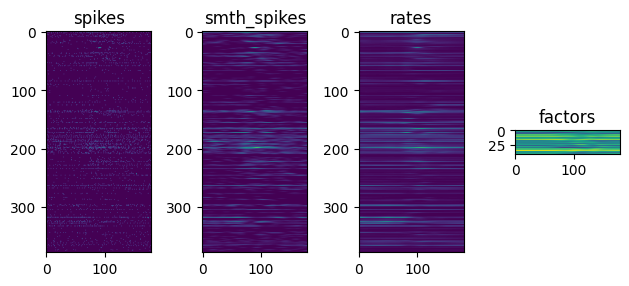

In [145]:
data = {
    "spikes": spike_tensor_binned,
    "smth_spikes": smth_spikes,
    "rates": train_rates,
    "factors": valid_factors,
    
}

trial = 0

fig, axes = plt.subplots(ncols=4)
for ax, (name, data_val) in zip(axes, data.items()):
    ax.imshow(data_val[trial].T)
    ax.set_title(name)
plt.tight_layout()

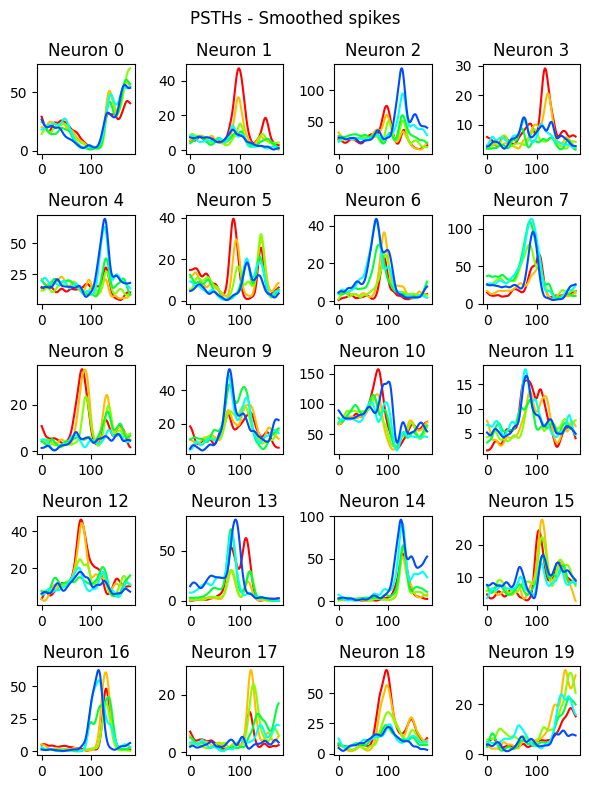

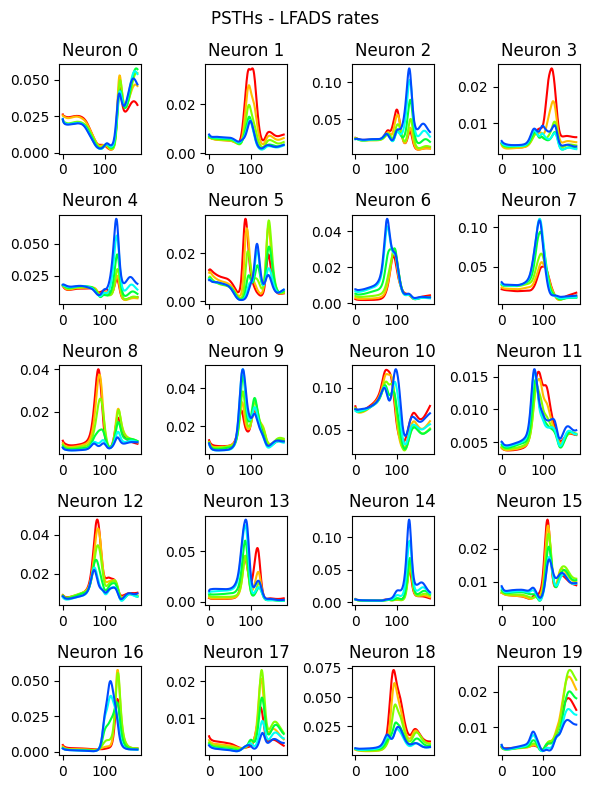

In [155]:
from matplotlib import cm

def plot_psths(data, conds, title):
    fig, axes = plt.subplots(5, 4, figsize=(6, 8))
    plot_conds = conds % 6
    for i, ax in enumerate(axes.flatten()):
        for c in np.unique(plot_conds):
            ax.plot(
                np.mean(data[plot_conds == c, :, i +100], axis=0),
                color=cm.hsv(c / 8),
            )
        ax.set_title(f"Neuron {i}")
    plt.suptitle(title)
    plt.tight_layout()

sess = "20170705"
plot_psths(smth_spikes, trial_conditions, "PSTHs - Smoothed spikes")
plot_psths(rates, trial_conditions, "PSTHs - LFADS rates")

In [147]:
psths.shape

(6, 180, 378)

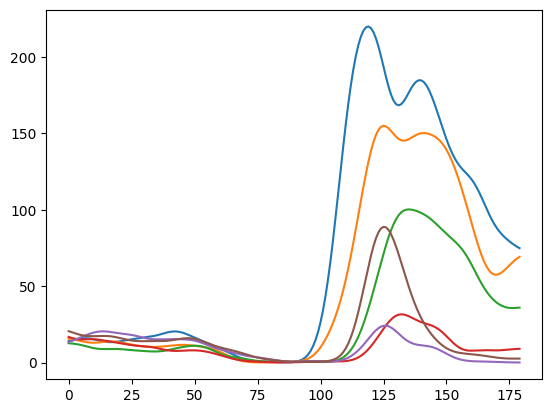

In [148]:
lfads_cond_avg = np.array([
    factors[trial_conditions == cond].mean(axis=0)
    for cond in trial_conditions
])

for condition in np.unique(trial_conditions):
    plt.plot(psths[int(condition)][:,21])     

In [139]:
rates.shape

(1023, 180, 378)

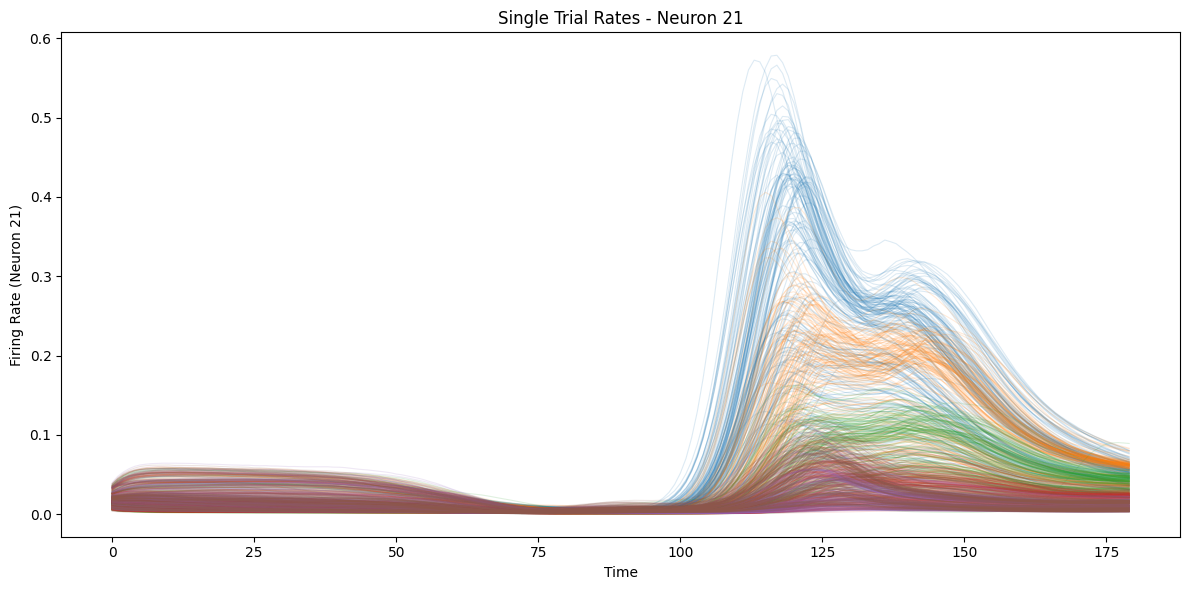

In [150]:
neuron = 21
fig, ax = plt.subplots(figsize=(12, 6))

colors = sns.color_palette("tab10", len(np.unique(trial_conditions)))

for condition in np.unique(trial_conditions):
    condition_mask = trial_conditions == condition
    rates_c = rates[condition_mask]
    
    for trial_rates in rates_c:
        ax.plot(trial_rates[:, neuron], 
                color=colors[int(condition)], 
                alpha=0.15,
                linewidth=0.8)

ax.set_xlabel('Time')
ax.set_ylabel(f'Firing Rate (Neuron {neuron})')
ax.set_title(f'Single Trial Rates - Neuron {neuron}')
plt.tight_layout()
plt.show()
    


## dPCA

In [151]:
import numpy as np

conditions = np.unique(trial_conditions)

factors_norm = factors - np.mean(factors, axis=0, keepdims=True)

lfads_cond_avg = np.array([
    factors_norm[trial_conditions == cond].mean(axis=0)
    for cond in conditions
])
lfads_cond_avg.shape

lfads_normalized = lfads_cond_avg # - lfads_cond_avg.mean(axis=0, keepdims=True)

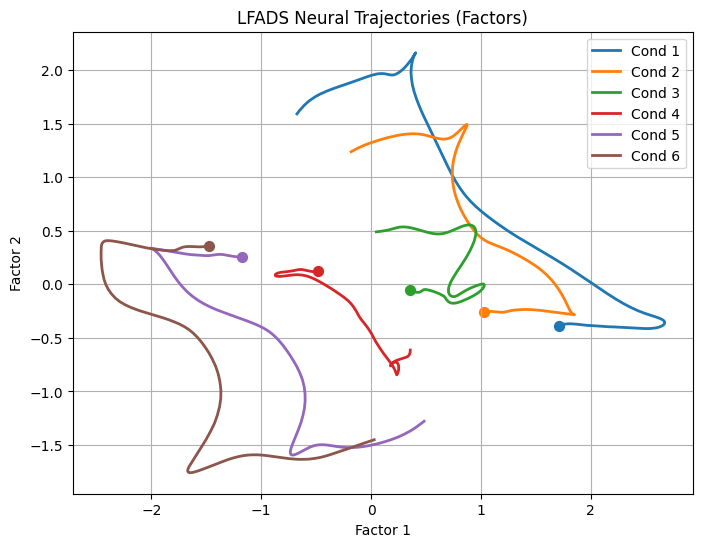

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA


C, T, F = lfads_cond_avg.shape

C, T, F = lfads_cond_avg.shape

X = lfads_normalized.reshape(C * T, F)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

lfads_pcs = X_pca.reshape(C, T, 3)

colors = sns.color_palette("tab10", C)
condition_labels = [f"Cond {i+1}" for i in range(C)]

fig, ax = plt.subplots(figsize=(8, 6))

for c in range(C):
    traj = lfads_pcs[c]  # (time, factors)

    ax.plot(
        traj[:, 0],   # Factor 1
        traj[:, 1],   # Factor 2
        color=colors[c],
        linewidth=2,
        label=condition_labels[c]
    )

    # mark start point
    ax.scatter(
        traj[0, 0],
        traj[0, 1],
        color=colors[c],
        s=50,
        marker='o'
    )

ax.set_xlabel('Factor 1')
ax.set_ylabel('Factor 2')
ax.set_title('LFADS Neural Trajectories (Factors)')
ax.legend()
ax.grid(True)

plt.show()

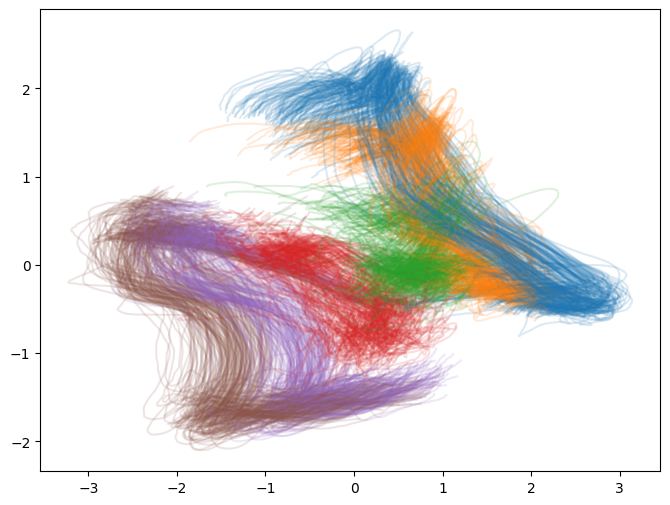

In [153]:
C, T, F = lfads_cond_avg.shape

colors = sns.color_palette("tab10", C)
condition_labels = [f"Cond {i+1}" for i in range(C)]

fig, ax = plt.subplots(figsize=(8, 6))

for trial in range(factors_norm.shape[0]):
    traj = factors_norm[trial]  # (time, factors_dim)
    traj_pca = pca.transform(traj)  

    ax.plot(
        traj_pca[:, 0],
        traj_pca[:, 1],
        color=colors[int(trial_conditions[trial])],
        alpha=0.15
    )

## dPCA



In [103]:
from dPCA import dPCA

T, N, K = lfads_normalized.shape

dpca = dPCA.dPCA(labels='st')

Z = dpca.fit_transform(lfads_normalized.transpose(2,0,1))

In [104]:
lfads_normalized.transpose(2,0,1).shape

(40, 6, 180)

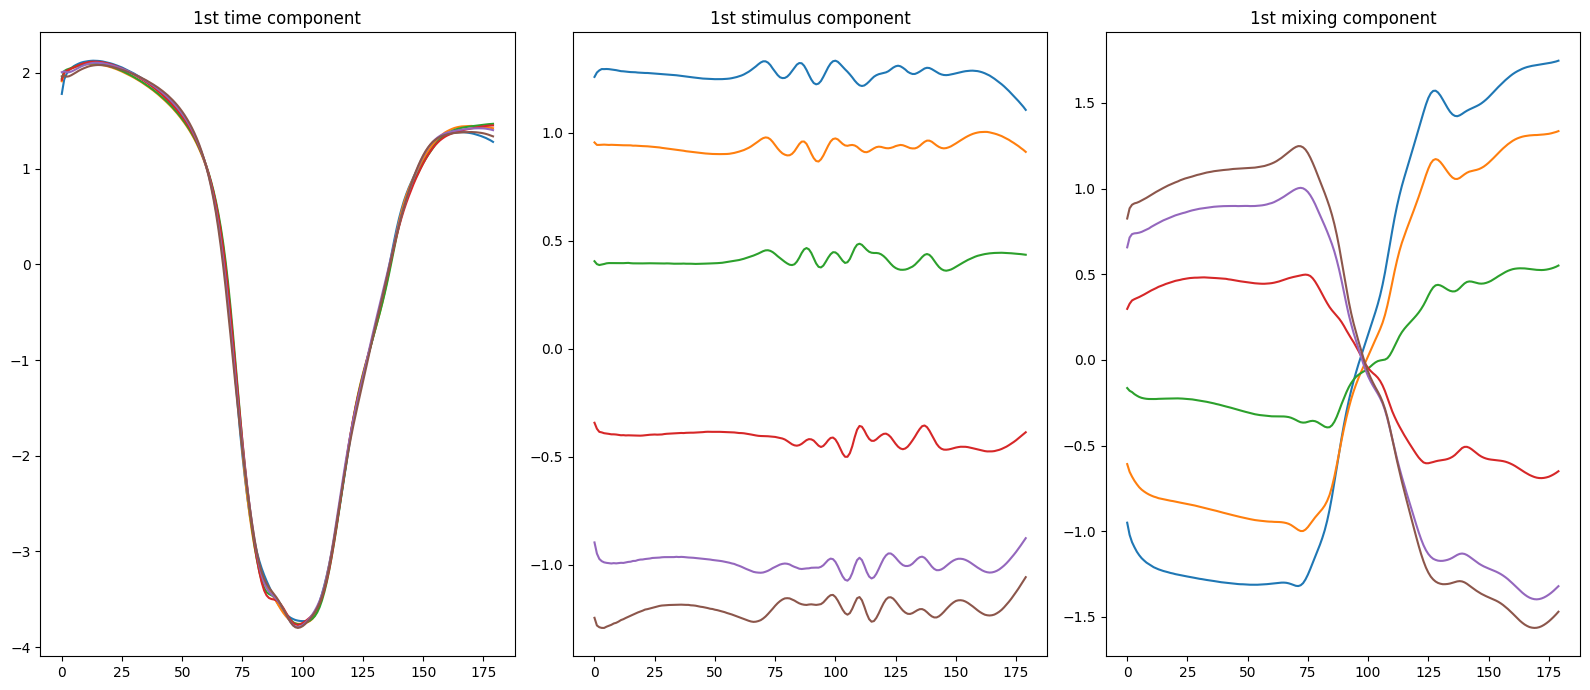

In [105]:
from numpy import *
from numpy.random import rand, randn, randint
import matplotlib.pyplot as plt

time = range(T)

# infer dimensions from dPCA output
S = Z['st'].shape[1]
T = Z['st'].shape[-1]
time = np.arange(T)

fig, axes = plt.subplots(1, 3, figsize=(16, 7))

for s in range(S):
    axes[0].plot(time, Z['t'][0, s])
axes[0].set_title('1st time component')

for s in range(S):
    axes[1].plot(time, Z['s'][0, s])
axes[1].set_title('1st stimulus component')

for s in range(S):
    axes[2].plot(time, Z['st'][0, s])
axes[2].set_title('1st mixing component')

plt.tight_layout()
plt.show()


0
1
2
3
4
5


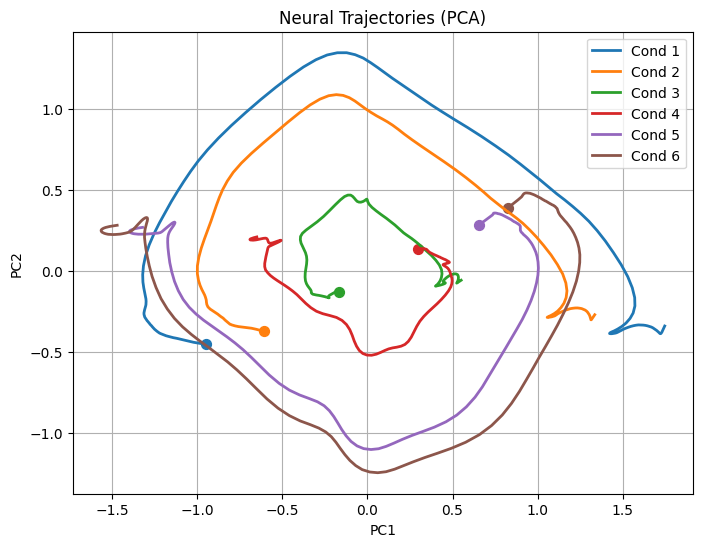

In [106]:
import seaborn as sns

# --- Create 2D figure ---
fig, ax = plt.subplots(figsize=(8, 6))

n_conditions, n_timesteps, n_components = psths.shape  # psth_pcs = (conditions × time × PCs)
condition_labels = [f"Cond {i+1}" for i in range(n_conditions)]
colors = sns.color_palette("tab10", n_conditions)  

for s in range(S):
    traj = Z['st'][:,s]  
    print(s)     # shape (time × n_components)
    ax.plot(
        traj[0,:],            # PC1
        traj[1,:],            # PC2
        linewidth=2,
        color=colors[s],
        label=condition_labels[s]
    )
    # mark start point
    ax.scatter(traj[0, 0], traj[1, 0], s=50, marker='o')

# --- Labels and title ---
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Neural Trajectories (PCA)')
ax.legend()
ax.grid(True)

plt.show()

In [69]:
import pandas as pd
import matplotlib.pyplot as plt


colors = plt.cm.coolwarm(np.linspace(0, 1, 2))

# Load your data
# Replace with your actual file path
df = pd.read_csv("/user_data/jpulidoa/lfads-torch/runs/lfads-torch-logic/logic_sr/260318_logicSingle/csv_logs/metrics.csv")

# Remove rows where epoch OR train/loss is NaN
df_clean = df.dropna(subset=["epoch", "train/loss"])

# Plot
plt.figure()
plt.plot(df_clean["epoch"], df_clean["train/loss"], label="Train Loss", color=colors[0])

# Optional: validation (also cleaned)
df_valid = df.dropna(subset=["epoch", "valid/loss"])
plt.plot(df_valid["epoch"], df_valid["valid/loss"], label="Validation Loss", color=colors[1])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()


plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/user_data/jpulidoa/lfads-torch/runs/lfads-torch-logic/logic_sr/260318_logicSingle/csv_logs/metrics.csv'